# F02 - Advanced Customer Segmentation
## Retail Customer Analytics using RFM and KMeans Clustering

In [1]:
import sys
!{sys.executable} -m pip install "numpy<2"

In [ ]:
import os
os._exit(00)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [32]:
!pip install xlrd

In [1]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Pranav\Downloads\Amdox internship\cleaned_feature_engineered_data.csv"
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Weekday,Weekend,PurchaseFrequency,MonetaryValue,Recency,OnlyDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday,False,6,2017.2,315,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,False,6,2017.2,315,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,False,6,2017.2,315,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,Tuesday,False,6,2017.2,315,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,Tuesday,False,6,2017.2,315,2009-12-01


In [2]:
df.shape

(400916, 18)

In [3]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day',
       'Weekday', 'Weekend', 'PurchaseFrequency', 'MonetaryValue', 'Recency',
       'OnlyDate'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400916 entries, 0 to 400915
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Invoice            400916 non-null  int64  
 1   StockCode          400916 non-null  object 
 2   Description        400916 non-null  object 
 3   Quantity           400916 non-null  int64  
 4   InvoiceDate        400916 non-null  object 
 5   Price              400916 non-null  float64
 6   Customer ID        400916 non-null  float64
 7   Country            400916 non-null  object 
 8   TotalPrice         400916 non-null  float64
 9   Year               400916 non-null  int64  
 10  Month              400916 non-null  int64  
 11  Day                400916 non-null  int64  
 12  Weekday            400916 non-null  object 
 13  Weekend            400916 non-null  bool   
 14  PurchaseFrequency  400916 non-null  int64  
 15  MonetaryValue      400916 non-null  float64
 16  Re

In [5]:
df.isnull().sum()

Invoice              0
StockCode            0
Description          0
Quantity             0
InvoiceDate          0
Price                0
Customer ID          0
Country              0
TotalPrice           0
Year                 0
Month                0
Day                  0
Weekday              0
Weekend              0
PurchaseFrequency    0
MonetaryValue        0
Recency              0
OnlyDate             0
dtype: int64

### Observation:

The dataset contains a large number of retail transactions from different customers and countries. Some missing values and duplicate entries were identified during initial exploration and were handled during preprocessing.

In [6]:
df.describe()

,Invoice,Quantity,Price,Customer ID,TotalPrice,Year,Month,Day,PurchaseFrequency,MonetaryValue,Recency
count,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000
mean,514731.380771,13.767418,3.305826,15361.544074,21.945330,2009.924493,7.398166,15.365368,18.617074,11388.408677,43.813153
std,14090.603233,97.638385,35.047719,1680.635823,77.758075,0.264208,3.472188,8.735086,34.361084,33206.051039,63.836400
min,489434.000000,1.000000,0.001000,12346.000000,0.001000,2009.000000,1.000000,1.000000,1.000000,2.950000,1.000000
25%,502752.000000,2.000000,1.250000,13985.000000,5.000000,2010.000000,4.000000,8.000000,3.000000,1160.410000,5.000000
50%,515192.000000,5.000000,1.950000,15311.000000,12.500000,2010.000000,8.000000,15.000000,7.000000,2610.910000,19.000000
75%,527065.500000,12.000000,3.750000,16805.000000,19.500000,2010.000000,11.000000,23.000000,15.000000,6493.140000,53.000000
max,538171.000000,19152.000000,10953.500000,18287.000000,15818.400000,2010.000000,12.000000,31.000000,205.000000,349164.350000,374.000000


In [7]:
df['Country'].value_counts().head(10)

Country
United Kingdom    364233
EIRE                8503
Germany             7645
France              5452
Netherlands         2728
Spain               1228
Switzerland         1170
Belgium             1036
Portugal             983
Sweden               867
Name: count, dtype: int64

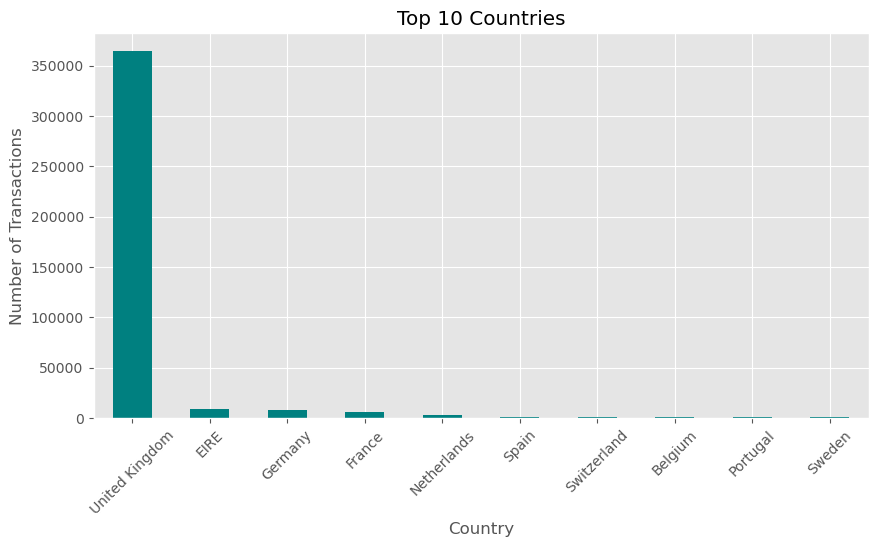

In [18]:
# -----------------------------------------
# Country-wise Customer Analysis
# Purpose:
# Identify top countries contributing
# to overall retail transactions.
# -----------------------------------------

plt.figure(figsize=(10,5))

df['Country'].value_counts().head(10).plot(
    kind='bar',
    color='teal'
)

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

### Observation:

Most transactions come from the United Kingdom, while the remaining countries contribute much smaller transaction volumes. This suggests the business is heavily concentrated in the UK market.

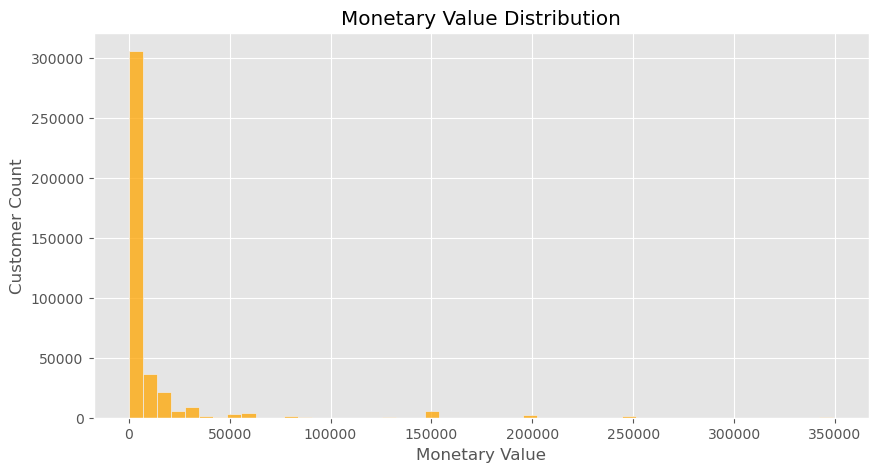

In [19]:
# -----------------------------------------
# Monetary Value Distribution
# Purpose:
# Analyze customer spending patterns.
# Helps identify high-value customers.
# -----------------------------------------

plt.figure(figsize=(10,5))

sns.histplot(
    df['MonetaryValue'],
    bins=50,
    color='orange'
)

plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Customer Count")

plt.show()

### Observation:

Most customers spend smaller amounts, while a few customers contribute very high revenue. There are some noticeable outliers in the dataset representing high-value customers.

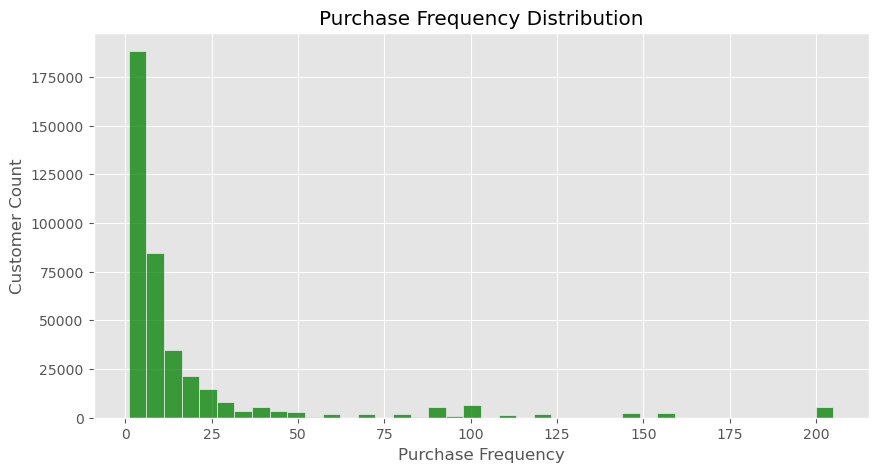

In [20]:
# -----------------------------------------
# Purchase Frequency Distribution
# Purpose:
# Understand repeat purchasing behavior.
# Helps identify loyal customers.
# -----------------------------------------

plt.figure(figsize=(10,5))

sns.histplot(
    df['PurchaseFrequency'],
    bins=40,
    color='green'
)

plt.title("Purchase Frequency Distribution")
plt.xlabel("Purchase Frequency")
plt.ylabel("Customer Count")

plt.show()

### Observation:

The majority of customers purchase only a few times, while a smaller group purchases very frequently. These frequent buyers are likely to be loyal customers.

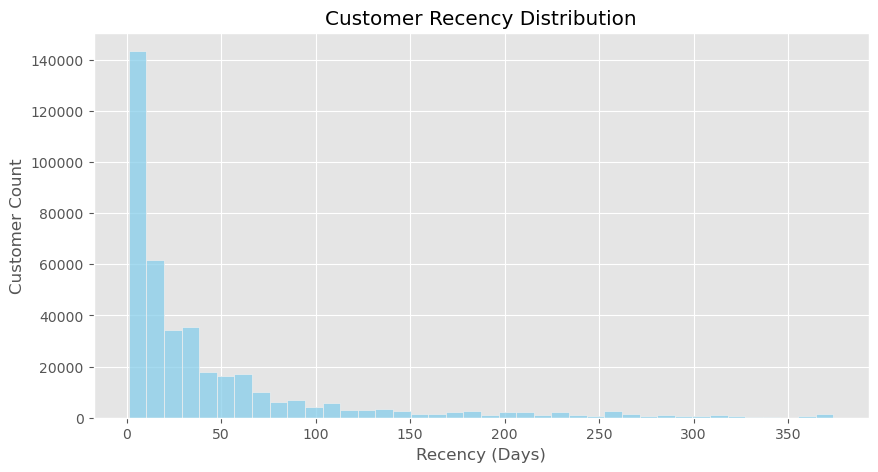

In [17]:
# -----------------------------------------
# Recency Distribution Analysis
# Purpose:
# Understand how recently customers made purchases.
# Lower recency = more active customers
# Higher recency = inactive/churn-risk customers
# -----------------------------------------

plt.figure(figsize=(10,5))

sns.histplot(
    df['Recency'],
    bins=40,
    color='skyblue'
)

plt.title("Customer Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Customer Count")

plt.show()

### Observation:

Many customers have lower recency values, meaning they purchased recently. Customers with higher recency values may represent inactive or churn-risk customers.

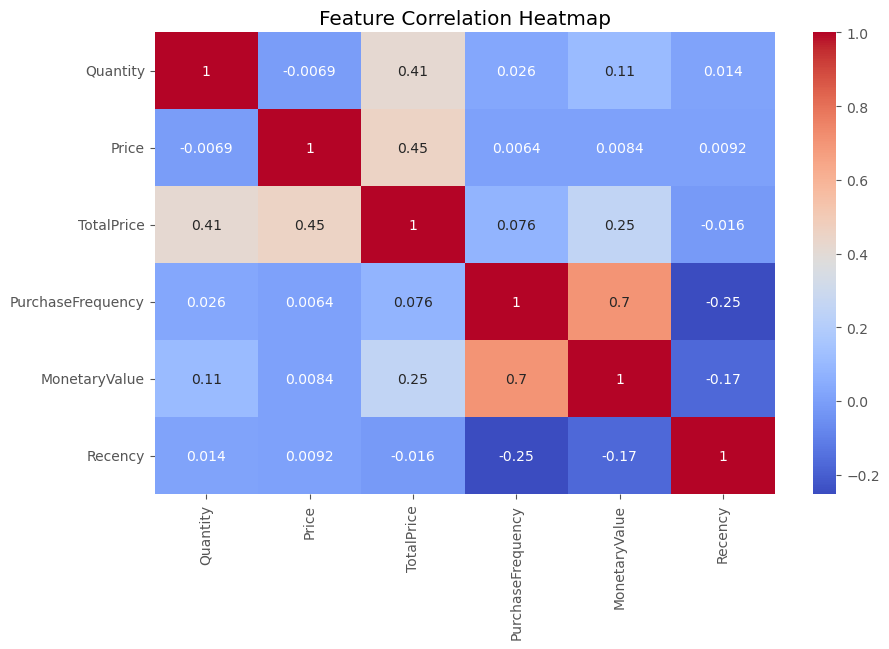

In [21]:
# -----------------------------------------
# Feature Correlation Heatmap
# Purpose:
# Identify relationships between
# important numerical features.
# -----------------------------------------

plt.figure(figsize=(10,6))

sns.heatmap(
    df[['Quantity',
        'Price',
        'TotalPrice',
        'PurchaseFrequency',
        'MonetaryValue',
        'Recency']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Observation:

Purchase Frequency and Monetary Value show a strong positive relationship. Customers who buy more frequently generally spend more money as well.

## RFM Feature Engineering

RFM Analysis is a customer segmentation technique used to analyze customer behavior based on:

- Recency → How recently a customer made a purchase
- Frequency → How often a customer purchases
- Monetary → How much money a customer spends

This helps identify loyal customers, inactive customers, and high-value customers.

In [22]:
# -----------------------------------------
# Creating RFM Table
# -----------------------------------------

rfm = df.groupby('Customer ID').agg({

    'Recency': 'min',
    'PurchaseFrequency': 'sum',
    'MonetaryValue': 'sum'

}).reset_index()

# Renaming columns

rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

# Display first rows

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,363,12304.38
1,12347.0,3,142,93955.72
2,12348.0,74,20,4443.20
3,12349.0,43,306,272456.28
4,12351.0,11,21,6319.53


### Observation:

RFM features provide a simplified way to understand customer behaviour using purchase recency, frequency, and spending patterns.

In [23]:
from sklearn.preprocessing import StandardScaler

# Selecting RFM features

rfm_data = rfm[['Recency', 'Frequency', 'Monetary']]

# Initializing scaler

scaler = StandardScaler()

# Scaling the data

rfm_scaled = scaler.fit_transform(rfm_data)

# Converting scaled array into dataframe

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

# Display scaled data

rfm_scaled.head()

,Recency,Frequency,Monetary
0,0.762299,-0.060759,-0.059516
1,-0.910402,-0.070575,-0.054873
2,-0.177305,-0.075994,-0.059963
3,-0.497389,-0.063291,-0.044722
4,-0.827799,-0.075949,-0.059856


### Observation:

Feature scaling helped normalize the RFM values before clustering, ensuring that no single feature dominates the model.

## Elbow Method for Optimal Cluster Selection

The Elbow Method is used to determine the optimal number of clusters for KMeans clustering.

The optimal cluster count is identified at the point where inertia begins decreasing more slowly.

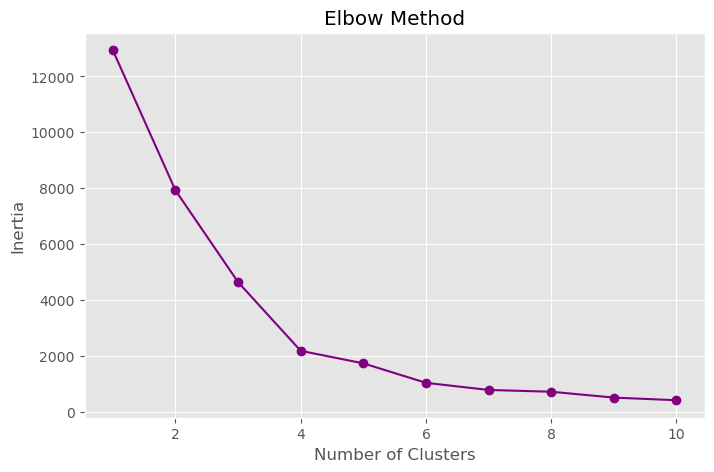

In [24]:
from sklearn.cluster import KMeans

# Empty list to store inertia values

inertia = []

# Testing cluster sizes from 1 to 10

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

# Plotting elbow graph

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o',
    color='purple'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

### Observation:

The elbow graph suggests that 4 clusters provide a reasonable balance between simplicity and cluster separation.

## Applying KMeans Clustering

KMeans clustering is used to group customers into different segments based on their purchasing behavior.

Customers with similar Recency, Frequency, and Monetary characteristics are grouped together.

In [25]:
from sklearn.cluster import KMeans

# Creating KMeans model

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Fitting the model

kmeans.fit(rfm_scaled)

# Assigning cluster labels

rfm['Cluster'] = kmeans.labels_

# Display first rows

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,165,363,12304.38,2
1,12347.0,3,142,93955.72,0
2,12348.0,74,20,4443.20,0
3,12349.0,43,306,272456.28,0
4,12351.0,11,21,6319.53,0


### Observation:
Customers have been successfully divided into multiple clusters based on their purchasing patterns.

Each cluster represents a unique customer segment with different behavioral characteristics.

## Cluster Visualization

The clusters are visualized to understand customer grouping patterns based on Frequency and Monetary Value.

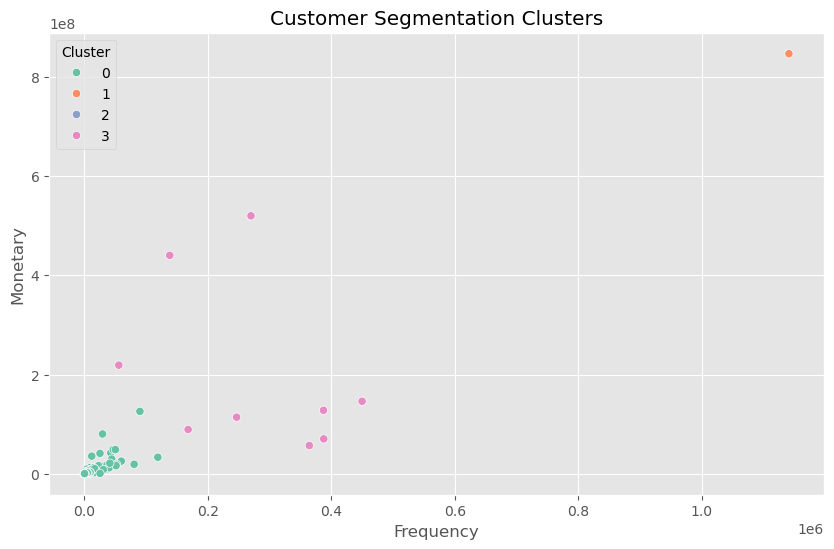

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segmentation Clusters")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

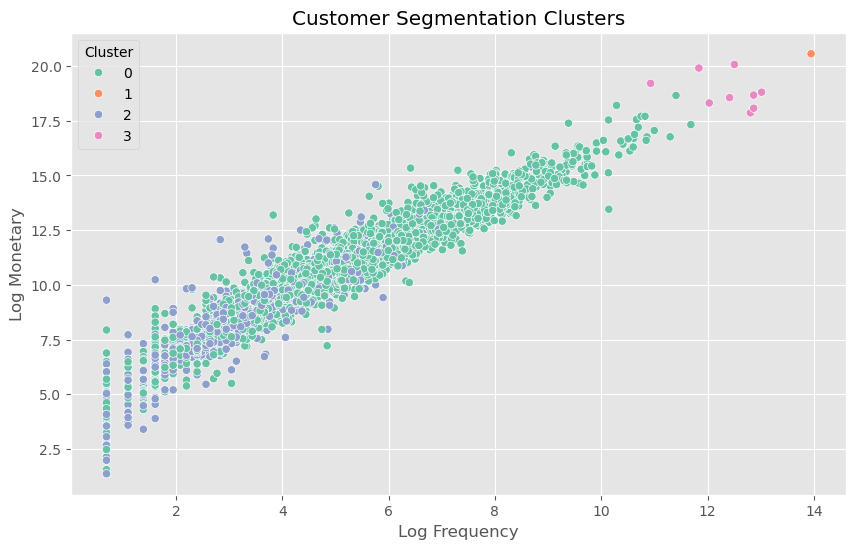

In [28]:
# -----------------------------------------
# Improved Cluster Visualization
# -----------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x=np.log1p(rfm['Frequency']),
    y=np.log1p(rfm['Monetary']),
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segmentation Clusters")
plt.xlabel("Log Frequency")
plt.ylabel("Log Monetary")

plt.show()

### Observation:

KMeans clustering grouped customers based on similar purchasing behaviour. Different clusters represent different types of customers in the dataset.

## 10. Cluster Analysis

This section analyzes the average customer behavior inside each cluster.

In [27]:
# Cluster-wise averages

cluster_analysis = rfm.groupby('Cluster').mean()

cluster_analysis

,CustomerID,Recency,Frequency,Monetary
Cluster,,,,
0,15330.267545,42.829605,1.155256e+03,5.808914e+05
1,14911.000000,1.000000,1.141440e+06,8.470110e+08
2,15409.256015,243.834456,8.148219e+01,3.794604e+04
3,15372.111111,3.888889,2.742424e+05,1.982122e+08


### Observation:
Cluster analysis helps identify:
- High-value loyal customers
- Low-engagement customers
- Frequent buyers
- Potential inactive customers

These insights can support targeted business and marketing strategies.

# Final Conclusion

This project successfully developed an AI-driven retail customer analytics system using Exploratory Data Analysis (EDA), RFM analysis, and machine learning clustering techniques.

Key outcomes of the project include:
- Understanding customer purchasing behaviour
- Identifying high-value and low-engagement customers
- Performing customer segmentation using K-Means clustering
- Generating business insights for marketing and retention strategies

The project demonstrated how machine learning and data analytics can help businesses:
- Improve customer targeting
- Increase customer retention
- Optimize sales strategies
- Support data-driven decision making

Overall, this system provides a strong foundation for intelligent retail analytics and future predictive customer behaviour analysis.